## **Experiment_02: Deep Feature Retrieval**

**Deep Feature Retrieval using Embeddings**

Experiment 01 showed that MSE and SSIM retrieve images mainly according to pixel alignment, global appearance, and camera viewpoint. In this experiment, we move from direct image comparison to feature-based retrieval.

Instead of comparing images pixel by pixel, each image is passed through a CNN feature extractor and represented as an embedding vector. Retrieval is then performed by comparing these embeddings using cosine similarity.

| Method | Description |
|---|---|
| [Pretrained ResNet50 Embeddings + Cosine Similarity](#resnet) | Uses a ResNet50 pretrained on ImageNet as a generic visual feature extractor. |
| [Pretrained ViT-B/16 Embeddings + Cosine Similarity](#vit) | Uses a Vision Transformer pretrained on ImageNet; attends globally across patches from the first layer. |
| [Task 2 CNN Embeddings + Cosine Similarity](#cnn) | Uses the CNN trained for ball counting as a task-specific feature extractor. |

Two feature extractors are evaluated:

1. **Pretrained ResNet (ImageNet)** – a generic visual representation learned from large-scale image classification.

2. **Task 2 CNN** – a billiard-specific network trained for ball counting, whose intermediate feature representations may capture information more relevant to table configurations.

The objective is to determine whether deep visual features provide a more meaningful retrieval representation than raw pixel similarity and whether task-specific features outperform generic pretrained features.

#### **Imports and paths**

In [30]:
from pathlib import Path
import sys
import os
# import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.metrics.pairwise import cosine_similarity

from torchvision import models
import torch.nn as nn
import torch

In [31]:
# Used in later experiments

# SEED = 42

# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)

In [32]:
PROJECT_ROOT = Path.cwd().parents[2]
DATA_DIR     = PROJECT_ROOT / "data"
RETRIEVAL_DIR = PROJECT_ROOT / "detection_and_retrieval" / "retrieval"

# Teacher's split (partition.csv, no external data)
TRAIN_IMAGES_DIR = DATA_DIR / "teacher_split" / "train" / "images"
TEST_IMAGES_DIR  = DATA_DIR / "teacher_split" / "test"  / "images"

if str(RETRIEVAL_DIR) not in sys.path:
    sys.path.append(str(RETRIEVAL_DIR))

RESULTS_DIR = RETRIEVAL_DIR / "outputs" / "experiment_02"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

assert TRAIN_IMAGES_DIR.exists(), f"Missing: {TRAIN_IMAGES_DIR}"
assert TEST_IMAGES_DIR.exists(),  f"Missing: {TEST_IMAGES_DIR}"

In [33]:
from utils.data import (
    get_resnet_transform, get_cnn_transform,
    load_retrieval_datasets_from_dirs,
    DirDataset, show_image, denormalize_image,
)
from utils.setup import get_device

#### **Load Dataset**

The retrieval pool is composed of the training images, while the query set is composed of the test images, following the split defined in `partition.csv`.

Each image is resized, center-cropped, converted to tensor format, and normalized using ImageNet statistics, matching the preprocessing used in the baseline notebook.

In [34]:
transform = get_resnet_transform()

retrieval_pool, query_data = load_retrieval_datasets_from_dirs(
    train_dir=TRAIN_IMAGES_DIR,
    test_dir=TEST_IMAGES_DIR,
    transform=transform,
    exclude_prefix="ext_",   # drop external-data images; original 207 only
)

print(f"Retrieval pool size : {len(retrieval_pool)}")
print(f"Query set size      : {len(query_data)}")

sample_img, sample_name = query_data[0]
print(f"Sample query filename   : {sample_name}")
print(f"Sample query tensor shape: {sample_img.shape}")
print(f"Sample query tensor dtype : {sample_img.dtype}")

Retrieval pool size : 207
Query set size      : 20
Sample query filename   : 107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg
Sample query tensor shape: torch.Size([3, 224, 224])
Sample query tensor dtype : torch.float32


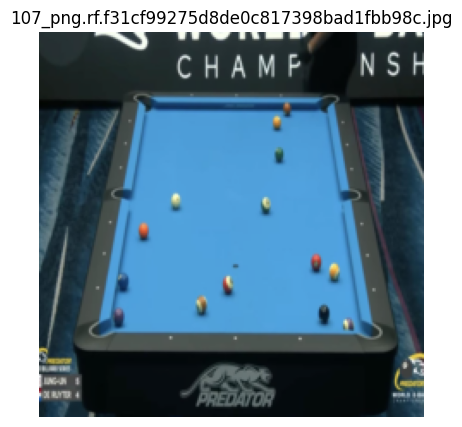

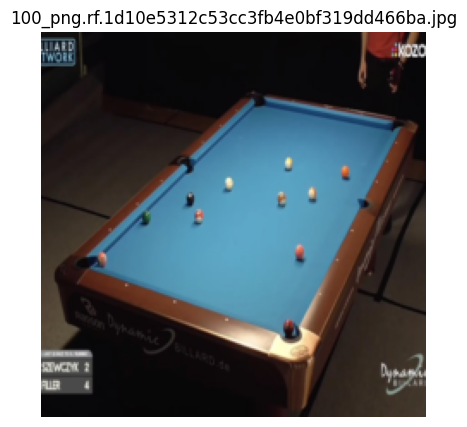

In [35]:
show_image(query_data, 0)
show_image(retrieval_pool, 1)

<a id="resnet"></a>
### **Pretrained ResNet Embeddings + Cosine Similarity**

Unlike MSE and SSIM, which compare images directly in pixel space, ResNet compares images in a learned feature space.

We use a ResNet pretrained on ImageNet as a feature extractor. The final classification layer is removed, and the activations of the last feature layer are used as image embeddings.

Retrieval is performed by:

1. **Extracting one embedding vector per image.**

2. **Computing cosine similarity between the query embedding and all retrieval-pool embeddings.**

3. **Ranking retrieval images according to similarity score.**

The expectation is that ResNet embeddings will be less sensitive to small pixel-level changes and may capture higher-level visual patterns than MSE or SSIM.

- #### **Load ResNet**

In [36]:
device = get_device()

Using mps


In [37]:
resnet = models.resnet50(weights="DEFAULT")

# Remove classification layer
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, ker

- #### **Embedding extraction**

In [38]:
def extract_embedding(model, image_tensor):
    """
    Extract a ResNet embedding from a single image.
    """
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        embedding = model(image_tensor)
        embedding = embedding.flatten()

    return embedding.cpu().numpy()

- #### **Query Example**

In [39]:
query_image, query_name = query_data[0]

query_embedding = extract_embedding(
    feature_extractor,
    query_image
)

print(query_embedding.shape)

(2048,)


- #### **Cosine Similarity Computation**

In [40]:
def get_topk_resnet(query_image, retrieval_pool, model, k=5):

    query_embedding = extract_embedding(model, query_image)

    scores = np.zeros(len(retrieval_pool))

    for i in tqdm(range(len(retrieval_pool))):
        candidate_image, _ = retrieval_pool[i]

        candidate_embedding = extract_embedding(
            model,
            candidate_image
        )

        scores[i] = cosine_similarity(
            query_embedding.reshape(1, -1),
            candidate_embedding.reshape(1, -1)
        )[0, 0]

    topk_idx = np.argsort(scores)[::-1][:k]

    return topk_idx, scores

- #### **Query Retrieval Example**

We first evaluate the retrieval behaviour on a single query image.

For the selected query, we extract its ResNet embedding, compute cosine similarity against all retrieval-pool embeddings, and retrieve the Top-5 most similar images.

In [41]:
top5_resnet_idx, similarities_resnet = get_topk_resnet(
    query_image=query_image,
    retrieval_pool=retrieval_pool,
    model=feature_extractor,
    k=5
)

print("Top-5 ResNet results:")
for rank, idx in enumerate(top5_resnet_idx, start=1):
    _, name = retrieval_pool[idx]

    print(
        f"{rank}. {name} | Cosine similarity = {similarities_resnet[idx]:.4f}"
    )

100%|██████████| 207/207 [00:08<00:00, 25.84it/s]

Top-5 ResNet results:
1. 120_png.rf.ad88298a705a565adab2f06fe083c434.jpg | Cosine similarity = 0.9552
2. 25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg | Cosine similarity = 0.9546
3. 106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg | Cosine similarity = 0.9539
4. 149_png.rf.9aba27d537b76bf911a1f4553acc6bc1.jpg | Cosine similarity = 0.9512
5. 132_png.rf.071b2e2111df71728a6b770afd959117.jpg | Cosine similarity = 0.9505


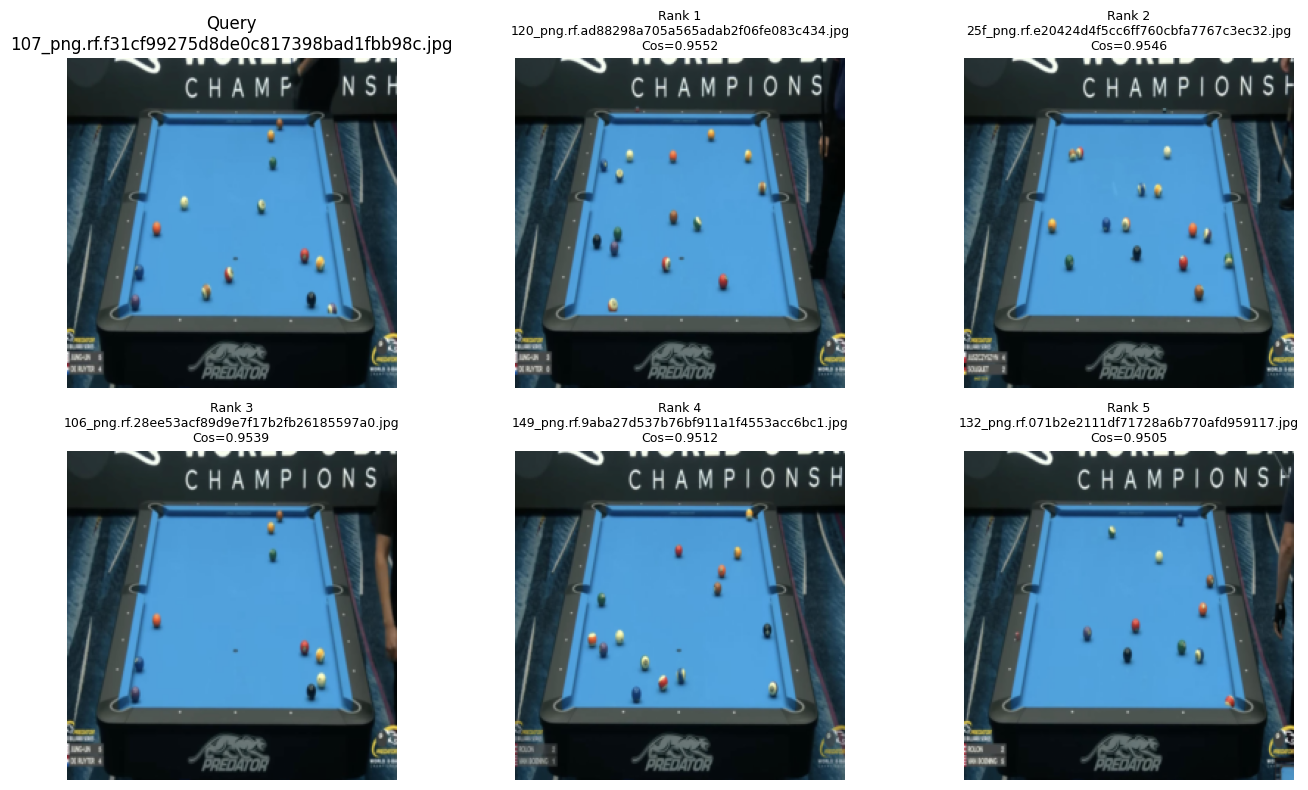

In [42]:
f, axarr = plt.subplots(2, 3, figsize=(14, 8))

axarr[0][0].imshow(denormalize_image(query_image))
axarr[0][0].set_title(f"Query\n{query_name}")
axarr[0][0].axis("off")

for j in range(1, 6):

    idx = top5_resnet_idx[j - 1]

    img, name = retrieval_pool[idx]

    axarr[j // 3][j % 3].imshow(
        denormalize_image(img)
    )

    axarr[j // 3][j % 3].set_title(
        f"Rank {j}\n{name}\nCos={similarities_resnet[idx]:.4f}",
        fontsize=9
    )

    axarr[j // 3][j % 3].axis("off")

plt.tight_layout()
plt.show()

- #### **ResNet Observations**

    - Compared with MSE and SSIM, ResNet retrieves images based on higher-level visual features rather than direct pixel similarity.

    - The retrieved images consistently share the same broadcast-style viewpoint and table appearance.

    - Similarity appears to be influenced by global scene structure and overall table occupancy.

    - However, several top-ranked images exhibit substantially different ball configurations.

    - These results suggest that pretrained ResNet embeddings provide a richer visual representation than pixel-based methods but still do not explicitly encode billiard-table state.
    
    - Viewpoint bias remains present, motivating the evaluation of task-specific embeddings learned from the Task 2 CNN.

<a id="cnn"></a>
### **Task 2 CNN + Cosine Similarity**

The second feature-based retrieval approach uses the CNN trained for Task 2 as a task-specific feature extractor.

Unlike the pretrained ResNet, which learns generic ImageNet features, the Task 2 CNN is trained on billiard-table images for ball counting. Therefore, its intermediate representations may encode information related to the number of balls, their visual appearance, and possibly their spatial distribution.

Retrieval is performed using the same strategy as before:

1. **Load the trained Task 2 CNN.**

2. **Remove or bypass the final prediction layer.**

3. **Extract one embedding vector per image.**

4. **Compare embeddings using cosine similarity.**

The objective is to evaluate whether task-specific features provide better retrieval behaviour than generic ResNet features.

In [43]:
# ============================================================
# TASK 2 CNN FEATURE EXTRACTOR
# ============================================================

import importlib.util
import torch.nn as nn

# Load BallCounterCNN directly from models/cnn_pipeline.py
_spec = importlib.util.spec_from_file_location(
    "cnn_pipeline", PROJECT_ROOT / "models" / "cnn_pipeline.py"
)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
BallCounterCNN = _mod.BallCounterCNN

WEIGHTS_PATH = PROJECT_ROOT / "models" / "best.pth" 

# Load full model with trained weights
cnn_full_model = BallCounterCNN()
cnn_full_model.load_state_dict(torch.load(str(WEIGHTS_PATH), map_location=device))
cnn_full_model.eval().to(device)

# Feature extractor: backbone only, bypassing the regression head.
# ResNet18 backbone outputs (B, 512, 1, 1) after global avg pool;
# flatten gives a 512-d embedding per image.
class CNNEmbedder(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x).flatten(1)

cnn_extractor = CNNEmbedder(cnn_full_model.backbone)
cnn_extractor.eval().to(device)

print(f"Weights : {WEIGHTS_PATH.name}")

# CNN-specific datasets at 384px (matches training input size)
cnn_transform = get_cnn_transform()
cnn_retrieval_pool, cnn_query_data = load_retrieval_datasets_from_dirs(
    train_dir=TRAIN_IMAGES_DIR,
    test_dir=TEST_IMAGES_DIR,
    transform=cnn_transform,
    exclude_prefix="ext_",
)

print(f"CNN retrieval pool: {len(cnn_retrieval_pool)} images")
print(f"CNN query set     : {len(cnn_query_data)} images")

with torch.no_grad():
    _emb = cnn_extractor(torch.zeros(1, 3, 384, 384).to(device))
print(f"Embedding dim     : {_emb.shape[1]}")

Weights : best.pth
CNN retrieval pool: 207 images
CNN query set     : 20 images
Embedding dim     : 512


### **Complete Retrieval**

To evaluate the ResNet embedding baseline on the full query set, we compute embeddings for all retrieval-pool images once and reuse them for every query.

This follows the standard retrieval pipeline:

1. **Offline phase:** compute and store embeddings for all training images.

2. **Query phase:** compute the query embedding, compare it with all stored embeddings, sort by cosine similarity, and return the Top-K results.

In [44]:
def compute_dataset_embeddings(dataset, model):
    embeddings = []
    filenames = []

    for img, name in tqdm(dataset):
        emb = extract_embedding(model, img)
        embeddings.append(emb)
        filenames.append(name)

    embeddings = np.vstack(embeddings)

    return embeddings, filenames


retrieval_embeddings, retrieval_filenames = compute_dataset_embeddings(
    retrieval_pool,
    feature_extractor
)

print(f"Retrieval embeddings shape: {retrieval_embeddings.shape}")
print(f"Number of retrieval filenames: {len(retrieval_filenames)}")

100%|██████████| 207/207 [00:07<00:00, 28.10it/s]

Retrieval embeddings shape: (207, 2048)
Number of retrieval filenames: 207


In [45]:
def get_topk_from_embeddings(query_image, model, retrieval_embeddings, k=5):
    query_embedding = extract_embedding(model, query_image)

    scores = cosine_similarity(
        query_embedding.reshape(1, -1),
        retrieval_embeddings
    )[0]

    topk_idx = np.argsort(scores)[::-1][:k]

    return topk_idx, scores

In [46]:
K = 5

resnet_results = []

for query_idx in tqdm(range(len(query_data))):
    query_image, query_name = query_data[query_idx]

    topk_idx, scores = get_topk_from_embeddings(
        query_image=query_image,
        model=feature_extractor,
        retrieval_embeddings=retrieval_embeddings,
        k=K
    )

    row = {
        "query_idx": query_idx,
        "query_name": query_name,
    }

    for rank in range(K):
        retrieved_idx = topk_idx[rank]
        retrieved_name = retrieval_filenames[retrieved_idx]

        row[f"resnet_rank{rank+1}_name"] = retrieved_name
        row[f"resnet_rank{rank+1}_score"] = scores[retrieved_idx]

    resnet_results.append(row)

resnet_results_df = pd.DataFrame(resnet_results)

resnet_results_df.head()

100%|██████████| 20/20 [00:00<00:00, 27.73it/s]


,query_idx,query_name,resnet_rank1_name,resnet_rank1_score,resnet_rank2_name,resnet_rank2_score,resnet_rank3_name,resnet_rank3_score,resnet_rank4_name,resnet_rank4_score,resnet_rank5_name,resnet_rank5_score
0,0,107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg,120_png.rf.ad88298a705a565adab2f06fe083c434.jpg,0.955244,25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg,0.954643,106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg,0.953915,149_png.rf.9aba27d537b76bf911a1f4553acc6bc1.jpg,0.951196,132_png.rf.071b2e2111df71728a6b770afd959117.jpg,0.950479
1,1,111_png.rf.573bdb8149674c4469ce560c651c6a48.jpg,166_png.rf.2a5fbe9b778584d26692a480bda6f22a.jpg,0.915575,21a_png.rf.34ea0016904d75da861731071be2058f.jpg,0.910906,108_png.rf.7bd2f9160e38391af93d2d6ebaaf966a.jpg,0.909394,4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg,0.905041,162_png.rf.faeb269d920f46126201519c32565e6d.jpg,0.904419
2,2,115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg,119_png.rf.eff91a09289a82f634d7b231b06dbbdd.jpg,0.963124,25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg,0.960888,120_png.rf.ad88298a705a565adab2f06fe083c434.jpg,0.951633,145_png.rf.223f80e4aff2b64f2711cd186532e118.jpg,0.949733,132_png.rf.071b2e2111df71728a6b770afd959117.jpg,0.949125
3,3,118_png.rf.3e82e1f3d657302b61a62c113271b753.jpg,162_png.rf.faeb269d920f46126201519c32565e6d.jpg,0.896179,169_png.rf.db5c4e716dac3be45044ffb904f0202d.jpg,0.893585,166_png.rf.2a5fbe9b778584d26692a480bda6f22a.jpg,0.889938,172_png.rf.fcfccb64edd6563c971ed5aadc369851.jpg,0.887837,170_png.rf.41755d44f9afc99e7cda8ff7b064d3e5.jpg,0.885578
4,4,134_png.rf.eafc70891a991c969df70bd817a63375.jpg,150_png.rf.d73327d3ac59114d003f79ec28e80c36.jpg,0.976536,6t_png.rf.3bfa7c04f03519e61d659108c308de32.jpg,0.975640,131_png.rf.593310c39f8835ed0786033b6690de45.jpg,0.974655,7t_png.rf.d593f52ab7cb17881fddcaf5de468819.jpg,0.974344,8t_png.rf.a49c210a8d59660de79ffdb07d55a6f6.jpg,0.973711


In [47]:
results_path = RESULTS_DIR / "retrieval_results_resnet.csv"

resnet_results_df.to_csv(results_path, index=False)

print(f"Saved ResNet retrieval results to: {results_path}")

Saved ResNet retrieval results to: /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/detection_and_retrieval/retrieval/outputs/experiment_02/retrieval_results_resnet.csv


In [48]:
resnet_summary = resnet_results_df[
    [
        "query_name",
        "resnet_rank1_name",
        "resnet_rank1_score",
        "resnet_rank2_name",
        "resnet_rank2_score",
        "resnet_rank3_name",
        "resnet_rank3_score",
        "resnet_rank4_name",
        "resnet_rank4_score",
        "resnet_rank5_name",
        "resnet_rank5_score",
    ]
]

resnet_summary

,query_name,resnet_rank1_name,resnet_rank1_score,resnet_rank2_name,resnet_rank2_score,resnet_rank3_name,resnet_rank3_score,resnet_rank4_name,resnet_rank4_score,resnet_rank5_name,resnet_rank5_score
0,107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg,120_png.rf.ad88298a705a565adab2f06fe083c434.jpg,0.955244,25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg,0.954643,106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg,0.953915,149_png.rf.9aba27d537b76bf911a1f4553acc6bc1.jpg,0.951196,132_png.rf.071b2e2111df71728a6b770afd959117.jpg,0.950479
1,111_png.rf.573bdb8149674c4469ce560c651c6a48.jpg,166_png.rf.2a5fbe9b778584d26692a480bda6f22a.jpg,0.915575,21a_png.rf.34ea0016904d75da861731071be2058f.jpg,0.910906,108_png.rf.7bd2f9160e38391af93d2d6ebaaf966a.jpg,0.909394,4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg,0.905041,162_png.rf.faeb269d920f46126201519c32565e6d.jpg,0.904419
2,115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg,119_png.rf.eff91a09289a82f634d7b231b06dbbdd.jpg,0.963124,25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg,0.960888,120_png.rf.ad88298a705a565adab2f06fe083c434.jpg,0.951633,145_png.rf.223f80e4aff2b64f2711cd186532e118.jpg,0.949733,132_png.rf.071b2e2111df71728a6b770afd959117.jpg,0.949125
3,118_png.rf.3e82e1f3d657302b61a62c113271b753.jpg,162_png.rf.faeb269d920f46126201519c32565e6d.jpg,0.896179,169_png.rf.db5c4e716dac3be45044ffb904f0202d.jpg,0.893585,166_png.rf.2a5fbe9b778584d26692a480bda6f22a.jpg,0.889938,172_png.rf.fcfccb64edd6563c971ed5aadc369851.jpg,0.887837,170_png.rf.41755d44f9afc99e7cda8ff7b064d3e5.jpg,0.885578
4,134_png.rf.eafc70891a991c969df70bd817a63375.jpg,150_png.rf.d73327d3ac59114d003f79ec28e80c36.jpg,0.976536,6t_png.rf.3bfa7c04f03519e61d659108c308de32.jpg,0.975640,131_png.rf.593310c39f8835ed0786033b6690de45.jpg,0.974655,7t_png.rf.d593f52ab7cb17881fddcaf5de468819.jpg,0.974344,8t_png.rf.a49c210a8d59660de79ffdb07d55a6f6.jpg,0.973711
5,136_png.rf.e99c3dfd6e84ce294cdabc3bb5ee8a75.jpg,150_png.rf.d73327d3ac59114d003f79ec28e80c36.jpg,0.978099,7t_png.rf.d593f52ab7cb17881fddcaf5de468819.jpg,0.972867,147_png.rf.f75092db32c867f5974bd801ebff4919.jpg,0.971586,138_png.rf.8f90a2d90a20d34006c446dc14a852c0.jpg,0.969092,159_png.rf.301cd8292389a32360fcde7abf681cfe.jpg,0.968883
6,140_png.rf.6645e10bad5cf3f197b71ddb6b34e6b4.jpg,142_png.rf.7094e2d69746d686d71b971d474ae84d.jpg,0.972352,132_png.rf.071b2e2111df71728a6b770afd959117.jpg,0.966510,120_png.rf.ad88298a705a565adab2f06fe083c434.jpg,0.965896,133_png.rf.a4164ecd79cdd480304adcf094cd17e3.jpg,0.962569,149_png.rf.9aba27d537b76bf911a1f4553acc6bc1.jpg,0.961736
7,144_png.rf.5c3890791bfecba0869eafb73fa3a4f5.jpg,143_png.rf.4ddb999b17c98b304ca30654dfd0b01c.jpg,0.984656,125_png.rf.746e605d23baaa43560542b8554b714c.jpg,0.982082,124_png.rf.1c7ed97791213cc079fccc558f1ad959.jpg,0.979297,5t_png.rf.8e895b792f2cfabbbbaf6eb62c6e2622.jpg,0.978936,159_png.rf.301cd8292389a32360fcde7abf681cfe.jpg,0.978860
8,181_png.rf.23ccd3b4b31a6fef484f7f0d25cf89d7.jpg,178_png.rf.5087fa5324451e07d2ed4f3d0e39b8e7.jpg,0.891688,188_png.rf.817e806abd4f5edc9588cc0dbf1a8616.jpg,0.873900,141_png.rf.29f059d54b07ead4d4680ae0a8a66ec4.jpg,0.870546,164_png.rf.adf1d66e8c2fa71261ca3f1d6852fa16.jpg,0.852761,177_png.rf.44e0980f0a0137fa46f4a9ac8c51e603.jpg,0.850576
9,185_png.rf.d2a971d3a33d7f290e313be493525277.jpg,187_png.rf.b5c19d9e137330a99f4a5885ac5c7d73.jpg,0.904161,154_png.rf.9667f3add0f6a1d344745423a5d13882.jpg,0.891944,178_png.rf.5087fa5324451e07d2ed4f3d0e39b8e7.jpg,0.891147,170_png.rf.41755d44f9afc99e7cda8ff7b064d3e5.jpg,0.883443,160_png.rf.6f41e2456edd6888c9fae22813acc55e.jpg,0.883140


In [49]:
# - #### **Embedding Pre-computation**

print("Pre-computing CNN embeddings for retrieval pool (207 images)...")
cnn_pool_embeddings, cnn_pool_filenames = compute_dataset_embeddings(
    cnn_retrieval_pool, cnn_extractor
)
print(f"Pool embeddings shape: {cnn_pool_embeddings.shape}")

Pre-computing CNN embeddings for retrieval pool (207 images)...


100%|██████████| 207/207 [00:07<00:00, 28.87it/s]

Pool embeddings shape: (207, 512)


In [50]:
# - #### **Query Retrieval Example**

cnn_query_image, cnn_query_name = cnn_query_data[0]

topk_cnn_idx, scores_cnn = get_topk_from_embeddings(
    cnn_query_image, cnn_extractor, cnn_pool_embeddings, k=5
)

print(f"Query: {cnn_query_name}")
print("Top-5 CNN results:")
for rank, idx in enumerate(topk_cnn_idx, start=1):
    print(f"  Rank {rank}: {cnn_pool_filenames[idx]}  (cosine={scores_cnn[idx]:.4f})")

Query: 107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg
Top-5 CNN results:
  Rank 1: 142_png.rf.7094e2d69746d686d71b971d474ae84d.jpg  (cosine=0.9985)
  Rank 2: 146_png.rf.8c716f42d6929f1b4c27cbfde0544e05.jpg  (cosine=0.9980)
  Rank 3: 24_png.rf.76109e322271997766d83ebb01eba055.jpg  (cosine=0.9978)
  Rank 4: 9t_png.rf.9fed287c2c696d2899ea436ef7e3d20d.jpg  (cosine=0.9977)
  Rank 5: 7t_png.rf.d593f52ab7cb17881fddcaf5de468819.jpg  (cosine=0.9976)


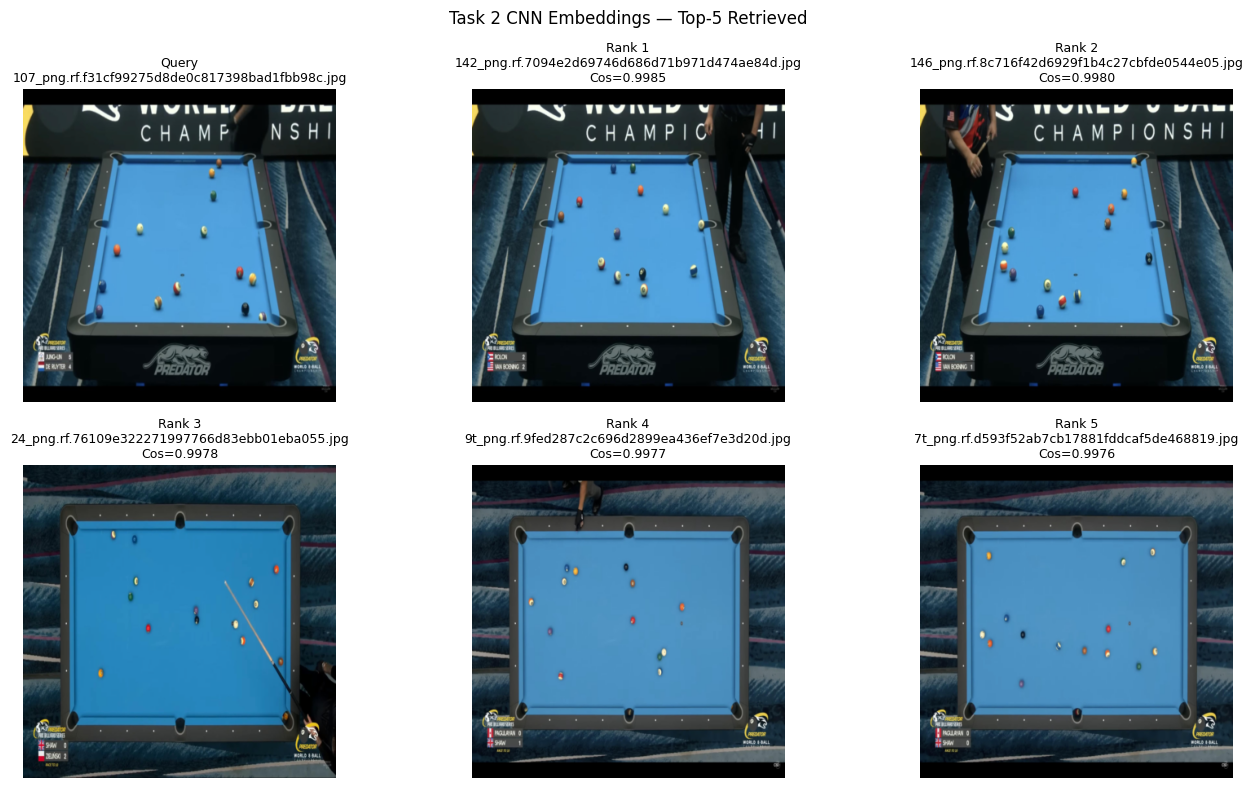

In [51]:
f, axarr = plt.subplots(2, 3, figsize=(14, 8))

axarr[0][0].imshow(denormalize_image(cnn_query_image))
axarr[0][0].set_title(f"Query\n{cnn_query_name}", fontsize=9)
axarr[0][0].axis("off")
axarr[0][1].axis("off")
axarr[0][2].axis("off")

for j in range(1, 6):
    idx = topk_cnn_idx[j - 1]
    img, name = cnn_retrieval_pool[idx]
    axarr[j // 3][j % 3].imshow(denormalize_image(img))
    axarr[j // 3][j % 3].set_title(
        f"Rank {j}\n{name}\nCos={scores_cnn[idx]:.4f}", fontsize=9
    )
    axarr[j // 3][j % 3].axis("off")

plt.suptitle("Task 2 CNN Embeddings — Top-5 Retrieved", fontsize=12)
plt.tight_layout()
plt.show()

- #### **CNN Observations**

    - **High and compressed cosine scores.** Almost all queries yield top-5 scores in the 0.995–0.999 range. This reflects a compressed embedding space: the backbone trained for ball counting maps all pool-table images into a tightly clustered region. The model learned strong domain-specific features, but the similarity scores have limited dynamic range — they do not strongly discriminate between different table states.

    - **Retrieves visually plausible images.** The retrieved images consistently show the same broadcast-style domain as the query (correct table, lighting, scoreboard), which is a clear improvement over MSE and SSIM that were purely pixel-level. The CNN correctly ignores superficial colour and texture variation.

    - **Viewpoint bias is not fully eliminated.** Top-view images (filenames with `t` suffix) appear in the top-5 for several broadcast-angle queries, indicating that the backbone features are not purely viewpoint-invariant. The counting task provided no explicit viewpoint supervision.

    - **Count-driven sensitivity.** Query 10 (`1_png`) is a clear outlier — its top-5 scores drop to 0.965–0.980, well below all other queries. This image likely has a very low ball count, and the counting-trained backbone encodes occupancy strongly enough to separate it from the dense-table majority.

    - **Multi-view recovery.** Query 19 (`9_png`) achieves a cosine of 0.9995 with its rank-1 result (`0_png`), the highest score in the entire retrieval set. These two images are likely different viewpoints of the same table state, suggesting the CNN embedding can naturally align multi-view images of identical configurations — a promising signal for state-based retrieval.

    - **Comparison with ResNet50.** ResNet50 scores ranged from approximately 0.87 to 0.96, providing more separation between images. CNN scores are higher but less spread, reflecting domain specialisation at the cost of retrieval discriminability. The CNN is better at identifying "same domain" but not necessarily "same table state".

In [52]:
# - #### **Complete Retrieval (CNN)**

K = 5
cnn_results = []

for query_idx in tqdm(range(len(cnn_query_data))):
    query_image, query_name = cnn_query_data[query_idx]

    topk_idx, scores = get_topk_from_embeddings(
        query_image=query_image,
        model=cnn_extractor,
        retrieval_embeddings=cnn_pool_embeddings,
        k=K,
    )

    row = {"query_idx": query_idx, "query_name": query_name}
    for rank in range(K):
        retrieved_idx = topk_idx[rank]
        row[f"cnn_rank{rank+1}_name"]  = cnn_pool_filenames[retrieved_idx]
        row[f"cnn_rank{rank+1}_score"] = scores[retrieved_idx]

    cnn_results.append(row)

cnn_results_df = pd.DataFrame(cnn_results)
cnn_results_df.head()

100%|██████████| 20/20 [00:00<00:00, 35.27it/s]


,query_idx,query_name,cnn_rank1_name,cnn_rank1_score,cnn_rank2_name,cnn_rank2_score,cnn_rank3_name,cnn_rank3_score,cnn_rank4_name,cnn_rank4_score,cnn_rank5_name,cnn_rank5_score
0,0,107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg,142_png.rf.7094e2d69746d686d71b971d474ae84d.jpg,0.998470,146_png.rf.8c716f42d6929f1b4c27cbfde0544e05.jpg,0.998010,24_png.rf.76109e322271997766d83ebb01eba055.jpg,0.997799,9t_png.rf.9fed287c2c696d2899ea436ef7e3d20d.jpg,0.997675,7t_png.rf.d593f52ab7cb17881fddcaf5de468819.jpg,0.997588
1,1,111_png.rf.573bdb8149674c4469ce560c651c6a48.jpg,23a_png.rf.c51e6e9452d0f5b24425c277e7e93085.jpg,0.997599,171_png.rf.e0f78688a6d730302708d2eec60a4bdf.jpg,0.997330,135_png.rf.8a27e2add3109c3d2fc762fd95669219.jpg,0.996643,86_png.rf.ed680afb145347de62fa9e5dd2b90bbe.jpg,0.996472,143_png.rf.4ddb999b17c98b304ca30654dfd0b01c.jpg,0.995950
2,2,115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg,130_png.rf.21f92398160a76a64b948884e4c8103c.jpg,0.998932,132_png.rf.071b2e2111df71728a6b770afd959117.jpg,0.998716,133_png.rf.a4164ecd79cdd480304adcf094cd17e3.jpg,0.998301,160_png.rf.6f41e2456edd6888c9fae22813acc55e.jpg,0.997325,153_png.rf.6e13f8c07bec12bd7e4094e6179bd363.jpg,0.997186
3,3,118_png.rf.3e82e1f3d657302b61a62c113271b753.jpg,15a_png.rf.d7f7746ea5afb68e6b42346c4990fa43.jpg,0.995697,1a_png.rf.17bf9820312efff2213b1d1b08ffad66.jpg,0.994729,4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg,0.994434,150_png.rf.d73327d3ac59114d003f79ec28e80c36.jpg,0.994358,77_png.rf.255db85931c9fbf597fd7c63e341d1dc.jpg,0.994258
4,4,134_png.rf.eafc70891a991c969df70bd817a63375.jpg,9t_png.rf.9fed287c2c696d2899ea436ef7e3d20d.jpg,0.998588,5t_png.rf.8e895b792f2cfabbbbaf6eb62c6e2622.jpg,0.998259,7t_png.rf.d593f52ab7cb17881fddcaf5de468819.jpg,0.998199,6t_png.rf.3bfa7c04f03519e61d659108c308de32.jpg,0.998159,131_png.rf.593310c39f8835ed0786033b6690de45.jpg,0.997946


In [53]:
cnn_results_path = RESULTS_DIR / "retrieval_results_cnn.csv"
cnn_results_df.to_csv(cnn_results_path, index=False)
print(f"Saved CNN retrieval results to: {cnn_results_path}")

Saved CNN retrieval results to: /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/detection_and_retrieval/retrieval/outputs/experiment_02/retrieval_results_cnn.csv


In [54]:
cnn_summary = cnn_results_df[[
    "query_name",
    "cnn_rank1_name", "cnn_rank1_score",
    "cnn_rank2_name", "cnn_rank2_score",
    "cnn_rank3_name", "cnn_rank3_score",
    "cnn_rank4_name", "cnn_rank4_score",
    "cnn_rank5_name", "cnn_rank5_score",
]]
cnn_summary

,query_name,cnn_rank1_name,cnn_rank1_score,cnn_rank2_name,cnn_rank2_score,cnn_rank3_name,cnn_rank3_score,cnn_rank4_name,cnn_rank4_score,cnn_rank5_name,cnn_rank5_score
0,107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg,142_png.rf.7094e2d69746d686d71b971d474ae84d.jpg,0.998470,146_png.rf.8c716f42d6929f1b4c27cbfde0544e05.jpg,0.998010,24_png.rf.76109e322271997766d83ebb01eba055.jpg,0.997799,9t_png.rf.9fed287c2c696d2899ea436ef7e3d20d.jpg,0.997675,7t_png.rf.d593f52ab7cb17881fddcaf5de468819.jpg,0.997588
1,111_png.rf.573bdb8149674c4469ce560c651c6a48.jpg,23a_png.rf.c51e6e9452d0f5b24425c277e7e93085.jpg,0.997599,171_png.rf.e0f78688a6d730302708d2eec60a4bdf.jpg,0.997330,135_png.rf.8a27e2add3109c3d2fc762fd95669219.jpg,0.996643,86_png.rf.ed680afb145347de62fa9e5dd2b90bbe.jpg,0.996472,143_png.rf.4ddb999b17c98b304ca30654dfd0b01c.jpg,0.995950
2,115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg,130_png.rf.21f92398160a76a64b948884e4c8103c.jpg,0.998932,132_png.rf.071b2e2111df71728a6b770afd959117.jpg,0.998716,133_png.rf.a4164ecd79cdd480304adcf094cd17e3.jpg,0.998301,160_png.rf.6f41e2456edd6888c9fae22813acc55e.jpg,0.997325,153_png.rf.6e13f8c07bec12bd7e4094e6179bd363.jpg,0.997186
3,118_png.rf.3e82e1f3d657302b61a62c113271b753.jpg,15a_png.rf.d7f7746ea5afb68e6b42346c4990fa43.jpg,0.995697,1a_png.rf.17bf9820312efff2213b1d1b08ffad66.jpg,0.994729,4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg,0.994434,150_png.rf.d73327d3ac59114d003f79ec28e80c36.jpg,0.994358,77_png.rf.255db85931c9fbf597fd7c63e341d1dc.jpg,0.994258
4,134_png.rf.eafc70891a991c969df70bd817a63375.jpg,9t_png.rf.9fed287c2c696d2899ea436ef7e3d20d.jpg,0.998588,5t_png.rf.8e895b792f2cfabbbbaf6eb62c6e2622.jpg,0.998259,7t_png.rf.d593f52ab7cb17881fddcaf5de468819.jpg,0.998199,6t_png.rf.3bfa7c04f03519e61d659108c308de32.jpg,0.998159,131_png.rf.593310c39f8835ed0786033b6690de45.jpg,0.997946
5,136_png.rf.e99c3dfd6e84ce294cdabc3bb5ee8a75.jpg,20t_png.rf.9c3224a237aafafb9884ca7c91a4ddb3.jpg,0.998076,16t_png.rf.119ab55b2bf60739d833fe614cf03c92.jpg,0.997592,153_png.rf.6e13f8c07bec12bd7e4094e6179bd363.jpg,0.997412,7t_png.rf.d593f52ab7cb17881fddcaf5de468819.jpg,0.997229,10t_png.rf.97c979f963b5a914b50a065e59ef3873.jpg,0.997222
6,140_png.rf.6645e10bad5cf3f197b71ddb6b34e6b4.jpg,22f_png.rf.5f4dedb3e61ea2ced7d183a74035d313.jpg,0.997900,119_png.rf.eff91a09289a82f634d7b231b06dbbdd.jpg,0.996084,145_png.rf.223f80e4aff2b64f2711cd186532e118.jpg,0.995781,129_png.rf.eb2bbec526ed5285770c494673de2c04.jpg,0.995762,104_png.rf.759632d10d5cf129aab09f0968304a4e.jpg,0.995710
7,144_png.rf.5c3890791bfecba0869eafb73fa3a4f5.jpg,19t_png.rf.379beff6ca036f9dfee92873c63e1c91.jpg,0.998327,14t_png.rf.3c97b229d4e5a2823995bdb9dbd1db76.jpg,0.998135,8t_png.rf.a49c210a8d59660de79ffdb07d55a6f6.jpg,0.997838,124_png.rf.1c7ed97791213cc079fccc558f1ad959.jpg,0.997494,125_png.rf.746e605d23baaa43560542b8554b714c.jpg,0.997466
8,181_png.rf.23ccd3b4b31a6fef484f7f0d25cf89d7.jpg,175_png.rf.3bb291132648e4ddc6318584b8fab3f6.jpg,0.997495,116_png.rf.d62651a8a8690338109c790bb5e036bd.jpg,0.996313,109_png.rf.0d8042ff3ef7a93feb5a18be8a42ca80.jpg,0.995719,164_png.rf.adf1d66e8c2fa71261ca3f1d6852fa16.jpg,0.994514,14a_png.rf.81c6d6e6686127d4274b4b8bbf8256b7.jpg,0.994452
9,185_png.rf.d2a971d3a33d7f290e313be493525277.jpg,156_png.rf.be7d3c328dad9ee7e3722259541a79d5.jpg,0.997311,32_png.rf.1edd41098eb074d061f00c09470d90cf.jpg,0.994179,39_png.rf.dc31e2cb0d05a0df89cfefc35ec71231.jpg,0.993078,31_png.rf.0f21d20a8cd7c12cbb1222cd2070b345.jpg,0.992442,40_png.rf.5bb1a2e7946b7a35cb9e87950cc508da.jpg,0.991065


<a id="vit"></a>
### **Pretrained ViT Embeddings + Cosine Similarity**

Vision Transformers (ViT) differ from CNNs in a key architectural way: they treat the image as a sequence of patches and apply self-attention globally from the very first layer. This means ViT builds relationships between distant regions of the image from the start, rather than through the progressive aggregation of local features that ResNet performs.

For retrieval, this could matter: a ViT may capture spatial co-occurrence of balls across the table more naturally than a CNN, even without task-specific training. We use the `[CLS]` token output as the image embedding (768-d for ViT-B/16), which aggregates information from all patches via attention.

In [55]:
# ViT-B/16 pretrained on ImageNet
# Replace classification head with Identity to expose the 768-d CLS token
vit = models.vit_b_16(weights="DEFAULT")
vit.heads = nn.Identity()
vit = vit.to(device)
vit.eval()

# Verify embedding dimension
with torch.no_grad():
    _emb = vit(torch.zeros(1, 3, 224, 224).to(device))
print(f"ViT-B/16 embedding dim: {_emb.shape[1]}")

# Reuse the same 224px retrieval pool already loaded for ResNet
print("Pre-computing ViT embeddings for retrieval pool...")
vit_pool_embeddings, vit_pool_filenames = compute_dataset_embeddings(retrieval_pool, vit)
print(f"Pool embeddings shape: {vit_pool_embeddings.shape}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /Users/gjoli/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:13<00:00, 26.4MB/s] 


ViT-B/16 embedding dim: 768
Pre-computing ViT embeddings for retrieval pool...


100%|██████████| 207/207 [00:40<00:00,  5.05it/s]

Pool embeddings shape: (207, 768)


Query: 107_png
Top-5 ViT results:
  Rank 1: 106_png  (cosine=0.9804)
  Rank 2: 25f_png  (cosine=0.9753)
  Rank 3: 130_png  (cosine=0.9745)
  Rank 4: 132_png  (cosine=0.9743)
  Rank 5: 149_png  (cosine=0.9734)


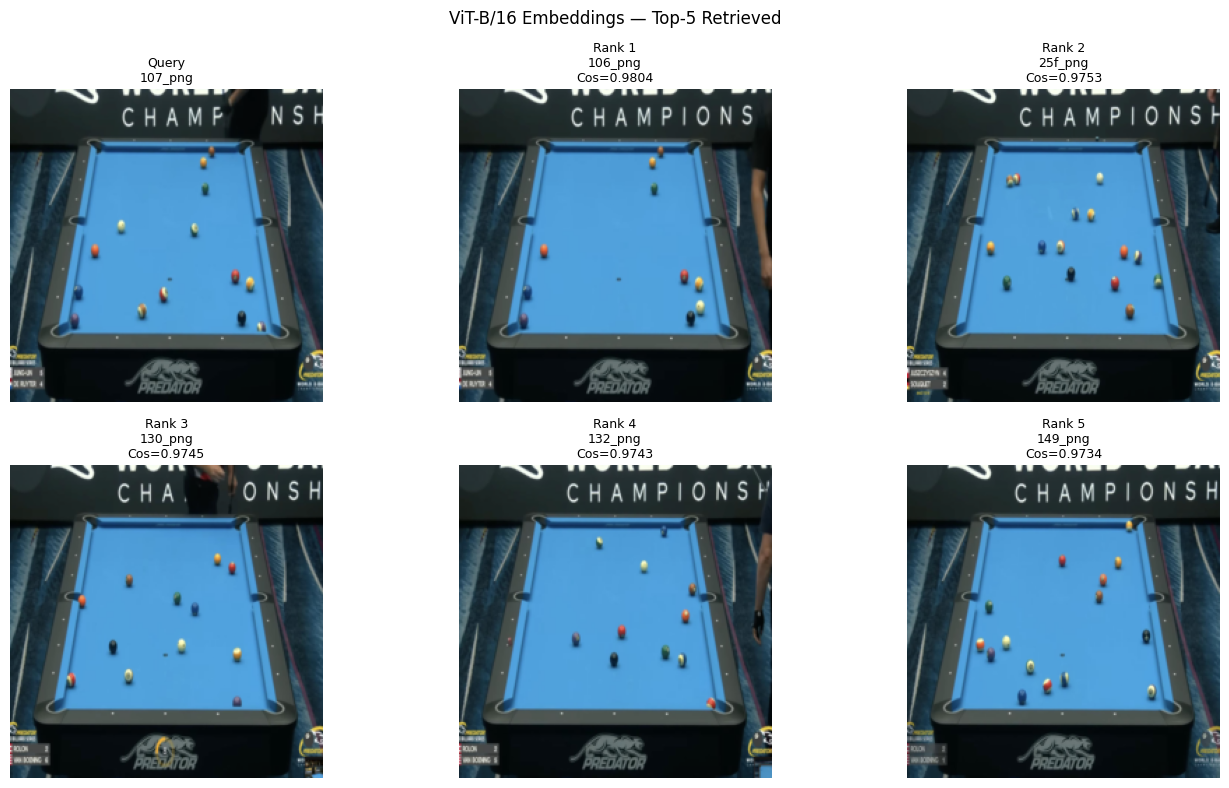

In [56]:
# Query example — idx 0
vit_query_image, vit_query_name = query_data[0]
topk_vit_idx, scores_vit = get_topk_from_embeddings(
    vit_query_image, vit, vit_pool_embeddings, k=5
)

print(f"Query: {vit_query_name.split('.rf.')[0]}")
print("Top-5 ViT results:")
for rank, idx in enumerate(topk_vit_idx, start=1):
    print(f"  Rank {rank}: {vit_pool_filenames[idx].split('.rf.')[0]}  (cosine={scores_vit[idx]:.4f})")

f, axarr = plt.subplots(2, 3, figsize=(14, 8))
axarr[0][0].imshow(denormalize_image(vit_query_image))
axarr[0][0].set_title(f"Query\n{vit_query_name.split('.rf.')[0]}", fontsize=9)
axarr[0][0].axis("off")

for j in range(1, 6):
    idx = topk_vit_idx[j - 1]
    img, name = retrieval_pool[idx]
    axarr[j // 3][j % 3].imshow(denormalize_image(img))
    axarr[j // 3][j % 3].set_title(
        f"Rank {j}\n{name.split('.rf.')[0]}\nCos={scores_vit[idx]:.4f}", fontsize=9
    )
    axarr[j // 3][j % 3].axis("off")

plt.suptitle("ViT-B/16 Embeddings — Top-5 Retrieved", fontsize=12)
plt.tight_layout()
plt.show()

In [57]:
K = 5
vit_results = []

for query_idx in tqdm(range(len(query_data))):
    query_image, query_name = query_data[query_idx]
    topk_idx, scores = get_topk_from_embeddings(
        query_image=query_image,
        model=vit,
        retrieval_embeddings=vit_pool_embeddings,
        k=K,
    )
    row = {"query_idx": query_idx, "query_name": query_name}
    for rank in range(K):
        retrieved_idx = topk_idx[rank]
        row[f"vit_rank{rank+1}_name"]  = vit_pool_filenames[retrieved_idx]
        row[f"vit_rank{rank+1}_score"] = scores[retrieved_idx]
    vit_results.append(row)

vit_results_df = pd.DataFrame(vit_results)

vit_results_path = RESULTS_DIR / "retrieval_results_vit.csv"
vit_results_df.to_csv(vit_results_path, index=False)
print(f"Saved ViT retrieval results to: {vit_results_path}")

vit_summary = vit_results_df[["query_name","vit_rank1_name","vit_rank1_score","vit_rank2_name","vit_rank2_score","vit_rank3_name","vit_rank3_score"]].copy()
vit_summary.columns = ["query","rank1","score1","rank2","score2","rank3","score3"]
for col in ["query","rank1","rank2","rank3"]:
    vit_summary[col] = vit_summary[col].str.split(".rf.").str[0]
print(vit_summary.to_string(index=False))

100%|██████████| 20/20 [00:04<00:00,  4.81it/s]

Saved ViT retrieval results to: /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/detection_and_retrieval/retrieval/outputs/experiment_02/retrieval_results_vit.csv
  query   rank1   score1   rank2   score2   rank3   score3
107_png 106_png 0.980387 25f_png 0.975340 130_png 0.974478
111_png 161_png 0.954243  5a_png 0.951349  86_png 0.949871
115_png 130_png 0.975447 25f_png 0.975276 132_png 0.973656
118_png 166_png 0.939544  4a_png 0.935199 21a_png 0.931923
134_png 131_png 0.975694 125_png 0.971100 150_png 0.970451
136_png 112_png 0.979098 157_png 0.971511 150_png 0.971012
140_png 132_png 0.978868 145_png 0.977784 123_png 0.974391
144_png  7t_png 0.980804 127_png 0.980627 150_png 0.979615
181_png 141_png 0.935048 162_png 0.883855 178_png 0.882756
185_png  89_png 0.942165 154_png 0.930047 108_png 0.926949
  1_png  92_png 0.943995  96_png 0.931081  90_png 0.917015
 21_png  34_png 0.973705 114_png 0.950819 135_png 0.947862
 26_png  36_png 0.971221  39_png 0.959339  16_png 0.95

- #### **ViT Observations**

    - **Score range ~0.88–0.99.** Slightly wider than ResNet50 (~0.87–0.96) but far wider than the Task 2 CNN (~0.965–0.999). The embedding space is discriminative yet not as compressed as the domain-specific model.

    - **Same session-mate behaviour as ResNet.** For `107_png` (14 balls), ViT retrieves `106_png` at rank 1 (cosine=0.9804) — the same broadcast match session with the same scoreboard visible. This is the same first-ranked result seen in ResNet50 and E3's proxy model, confirming that scene-level context (arena, banner, broadcast framing) is the dominant signal regardless of architecture.

    - **Misses retrieval pairs that ResNet and CNN both find.** For `144_png` (15 balls), both ResNet50 and the Task 2 CNN retrieve `143_png` (15 balls, same session) at rank 1. ViT instead retrieves `7t_png` (14 balls) — a complete miss. ViT's global self-attention appears to weight scene background more heavily than local table content, causing it to diverge from the session-based retrieval that benefits the other models.

    - **Quantitatively the worst on precision.** P@1=0.100 and P@5=0.060, below ResNet50 (P@1=0.150, P@5=0.110). Global attention was expected to capture spatial ball co-occurrence across the table, but instead amplifies scene-level context (venue appearance, broadcast framing, scoreboard) and produces weaker ball-count alignment than even the simpler CNN feature extraction.

    - **Better than ResNet on MAE@1.** Although ViT rarely hits the exact ball count at rank 1, when wrong it is typically less wrong by count (MAE@1=2.65 vs ResNet's 3.30). The patch-level attention may capture some coarse occupancy information without explicit count supervision — but this advantage is minor compared with the Task 2 CNN (MAE@1=0.95).

    - **Takeaway.** Architectural capacity for global reasoning does not help when the dominant visual signal in the data is scene appearance rather than ball configuration. ViT's ImageNet features are at least as biased toward viewpoint and venue as ResNet's — and the global attention mechanism appears to over-weight scene context even further.

### **Retrieval Evaluation**

We evaluate retrieval quality using **ball count** as ground truth: a retrieved image is a hit if it has the same number of balls as the query.

Metrics:
- **P@1** — does the rank-1 image have the same ball count as the query?
- **P@5** — fraction of the top-5 images with the same ball count
- **MAE@1** — absolute ball count difference between query and rank-1 image

In [58]:
TRAIN_LABELS_DIR = DATA_DIR / "teacher_split" / "train" / "labels"
TEST_LABELS_DIR  = DATA_DIR / "teacher_split" / "test"  / "labels"

def ball_count(fname, labels_dir):
    p = Path(labels_dir) / (Path(fname).stem + ".txt")
    if not p.exists():
        return None
    return sum(1 for ln in p.read_text().splitlines() if ln.strip() and not ln.startswith('2 '))

pool_counts  = {f: ball_count(f, TRAIN_LABELS_DIR) for f in retrieval_filenames}
query_counts = {row['query_name']: ball_count(row['query_name'], TEST_LABELS_DIR)
                for _, row in resnet_results_df.iterrows()}

K = 5
rows = []
for i, row in resnet_results_df.iterrows():
    q_name  = row['query_name']
    q_count = query_counts[q_name]

    resnet_top5 = [row[f'resnet_rank{k}_name'] for k in range(1, K+1)]
    cnn_top5    = [cnn_results_df.loc[i, f'cnn_rank{k}_name'] for k in range(1, K+1)]
    vit_top5    = [vit_results_df.loc[i, f'vit_rank{k}_name'] for k in range(1, K+1)]

    rows.append({
        'query':       q_name.split('.rf.')[0],
        'q_count':     q_count,
        'resnet_hit1': int(pool_counts[resnet_top5[0]] == q_count),
        'resnet_p5':   sum(pool_counts[f] == q_count for f in resnet_top5) / K,
        'resnet_mae1': abs(pool_counts[resnet_top5[0]] - q_count),
        'vit_hit1':    int(pool_counts[vit_top5[0]] == q_count),
        'vit_p5':      sum(pool_counts[f] == q_count for f in vit_top5) / K,
        'vit_mae1':    abs(pool_counts[vit_top5[0]] - q_count),
        'cnn_hit1':    int(pool_counts[cnn_top5[0]] == q_count),
        'cnn_p5':      sum(pool_counts[f] == q_count for f in cnn_top5) / K,
        'cnn_mae1':    abs(pool_counts[cnn_top5[0]] - q_count),
    })

eval_df = pd.DataFrame(rows)

print(f"{'Query':<10}  {'N':>2}  {'ResNet':>3}  {'ViT':>3}  {'CNN':>3}")
print('-' * 32)
for _, r in eval_df.iterrows():
    rt = '✓' if r['resnet_hit1'] else '✗'
    vt = '✓' if r['vit_hit1']   else '✗'
    ct = '✓' if r['cnn_hit1']   else '✗'
    print(f"  {r['query']:<10}  {r['q_count']:>2}  {rt:>3}  {vt:>3}  {ct:>3}")

print()
print(f"{'Metric':<22}  {'ResNet50':>10}  {'ViT-B/16':>10}  {'Task2 CNN':>10}")
print('-' * 58)
print(f"  {'P@1 (exact count)':<20}  {eval_df['resnet_hit1'].mean():>10.3f}  {eval_df['vit_hit1'].mean():>10.3f}  {eval_df['cnn_hit1'].mean():>10.3f}")
print(f"  {'P@5 (exact count)':<20}  {eval_df['resnet_p5'].mean():>10.3f}  {eval_df['vit_p5'].mean():>10.3f}  {eval_df['cnn_p5'].mean():>10.3f}")
print(f"  {'MAE@1 (ball count)':<20}  {eval_df['resnet_mae1'].mean():>10.3f}  {eval_df['vit_mae1'].mean():>10.3f}  {eval_df['cnn_mae1'].mean():>10.3f}")

Query        N  ResNet  ViT  CNN
--------------------------------
  107_png     14    ✗    ✗    ✗
  111_png     16    ✗    ✗    ✓
  115_png     11    ✗    ✗    ✗
  118_png     10    ✗    ✗    ✗
  134_png     13    ✗    ✗    ✓
  136_png     12    ✗    ✗    ✗
  140_png      8    ✗    ✗    ✗
  144_png     15    ✓    ✗    ✓
  181_png     16    ✗    ✗    ✓
  185_png      4    ✗    ✗    ✗
  1_png        2    ✗    ✗    ✓
  21_png      13    ✗    ✗    ✗
  26_png      10    ✗    ✗    ✗
  27_png      16    ✓    ✓    ✓
  38_png       8    ✗    ✓    ✗
  49_png      13    ✗    ✗    ✗
  52_png      12    ✓    ✗    ✓
  58_png       8    ✗    ✗    ✗
  94_png       9    ✗    ✗    ✗
  9_png        7    ✗    ✗    ✗

Metric                    ResNet50    ViT-B/16   Task2 CNN
----------------------------------------------------------
  P@1 (exact count)          0.150       0.100       0.350
  P@5 (exact count)          0.110       0.060       0.310
  MAE@1 (ball count)         3.300       2.650       0.95

### **Experiment 02 Conclusion**

**Evaluation results**

Ball count is used as ground truth: a retrieval is a hit if the rank-1 image has the same number of balls as the query.

| Metric | ResNet50 | ViT-B/16 | Task 2 CNN |
|---|---|---|---|
| P@1 (exact ball count) | 0.150 | 0.100 | **0.350** |
| P@5 (exact ball count) | 0.110 | 0.060 | **0.310** |
| MAE@1 (ball count error) | 3.300 | 2.650 | **0.950** |
| Embedding dim | 2048-d | 768-d | 512-d |
| Rank-1 sim range | ~0.87–0.96 | ~0.88–0.99 | ~0.965–0.999 |

**Method comparison**

| Method | Architecture | Key driver |
|---|---|---|
| ResNet50 (ImageNet) | CNN — local-to-global features | Generic visual semantics |
| ViT-B/16 (ImageNet) | Transformer — global attention from layer 1 | Patch co-occurrence, global context |
| Task 2 CNN (ResNet18) | CNN — domain-specific counting features | Billiard occupancy and density |

**Task 2 CNN dominates across every metric.** P@1=0.350 (7/20 queries correct at rank 1) is more than double ResNet50 (3/20) and more than triple ViT-B/16 (2/20). MAE@1=0.95 means the CNN is off by less than one ball on average at rank 1 — compared with ResNet's 3.30 and ViT's 2.65. The counting-specific backbone features encode ball density and occupancy as the dominant signal, which is exactly what ball-count retrieval measures. This result demonstrates that domain-specific training provides a stronger retrieval prior than general-purpose ImageNet features, even without any explicit retrieval objective.

**ViT-B/16 is the weakest on precision** (P@1=0.100, P@5=0.060), performing worse than ResNet50 despite its greater architectural capacity. Global self-attention amplifies scene-level context (venue banner, scoreboard, broadcast framing) rather than table content, causing it to retrieve same-session images rather than same-count images. It does achieve the best MAE@1 among the two ImageNet baselines (2.65 vs 3.30), suggesting some coarse occupancy sensitivity from patch attention — but the improvement is minor.

**ResNet50** retrieves images sharing the same broad visual context (broadcast style, table colour, overall occupancy) and exhibits viewpoint bias, scoring in between the other two models.

**Shared limitation.** None of the three embeddings explicitly represents the spatial position of individual balls. All methods are dominated by global features — table colour, viewpoint, broadcast style, total occupancy — rather than fine-grained ball layout. True state-based retrieval requires reasoning about where balls are located relative to the table geometry, motivating the top-view normalised approach in Experiment 04.